In [ ]:
!pip install yfinance pandas numpy arch scikit-learn matplotlib seaborn ta tensorflow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.2 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=9d17bf40351bf32069ddd2d0fd99f9b67370e1182fd57588b045dc091deba13a
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


/tmp/ipython-input-2747/4118848415.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2747/4118848415.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start='2010-01-01', end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed


First few rows of the dataset:
Price             Close         High          Low         Open      Volume  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC   
Date                                                                         
2010-01-04  1132.989990  1133.869995  1116.560059  1116.560059  3991400000   
2010-01-05  1136.520020  1136.630005  1129.660034  1132.660034  2491020000   
2010-01-06  1137.140015  1139.189941  1133.949951  1135.709961  4972660000   
2010-01-07  1141.689941  1142.459961  1131.319946  1136.270020  5270680000   
2010-01-08  1144.979980  1145.390015  1136.219971  1140.520020  4389590000   

Price             VIX  
Ticker           ^VIX  
Date                   
2010-01-04  20.040001  
2010-01-05  19.350000  
2010-01-06  19.160000  
2010-01-07  19.059999  
2010-01-08  18.129999  

Missing values in the dataset:
Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
VIX  

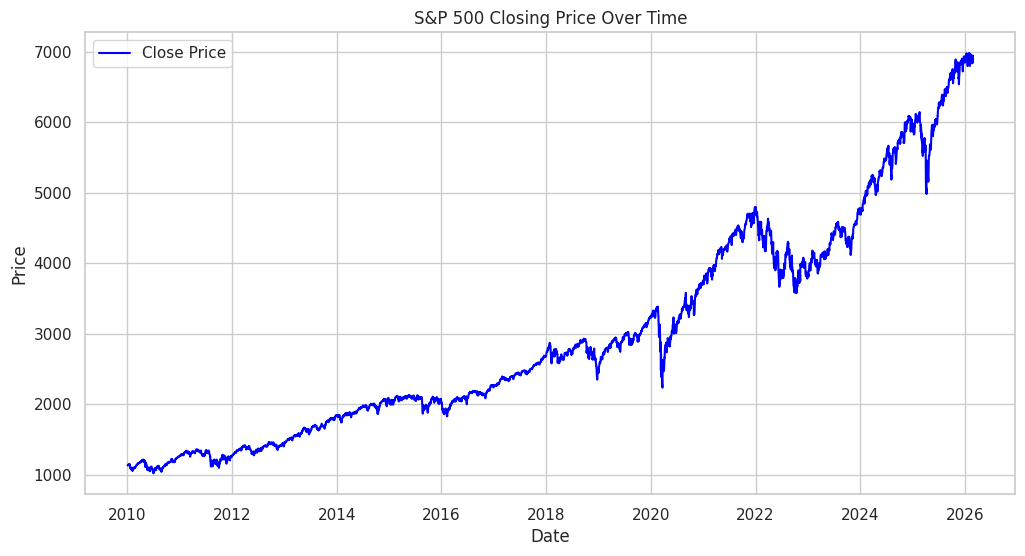

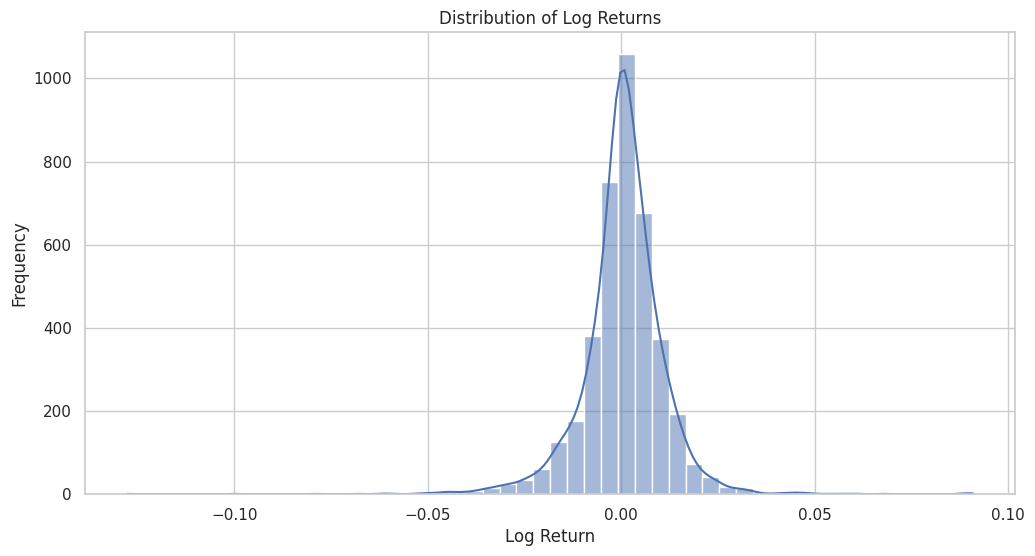

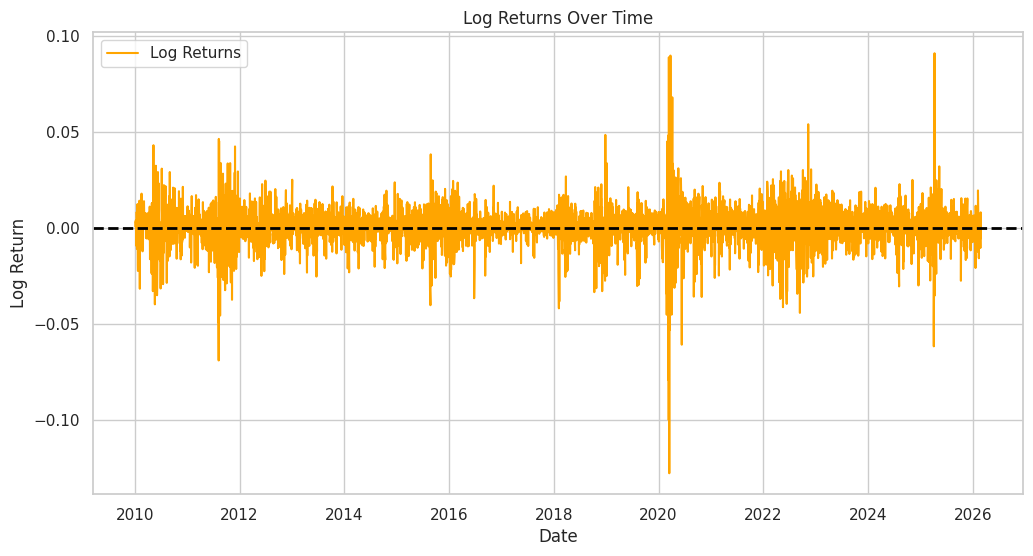

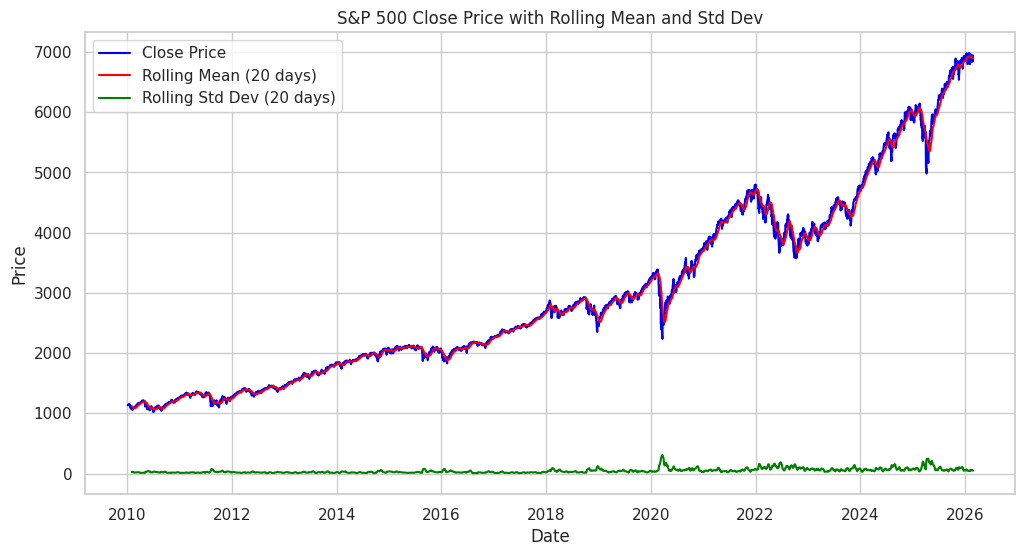

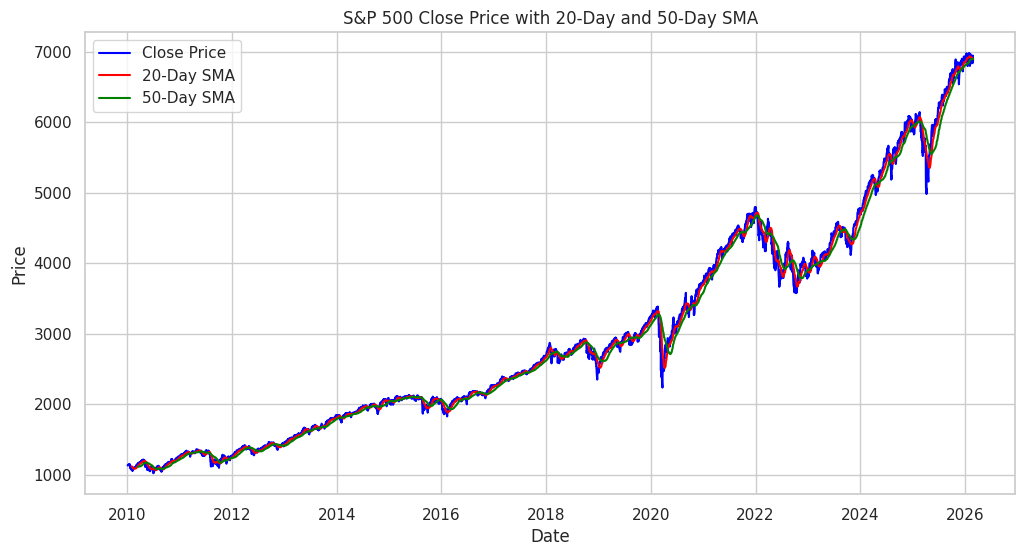

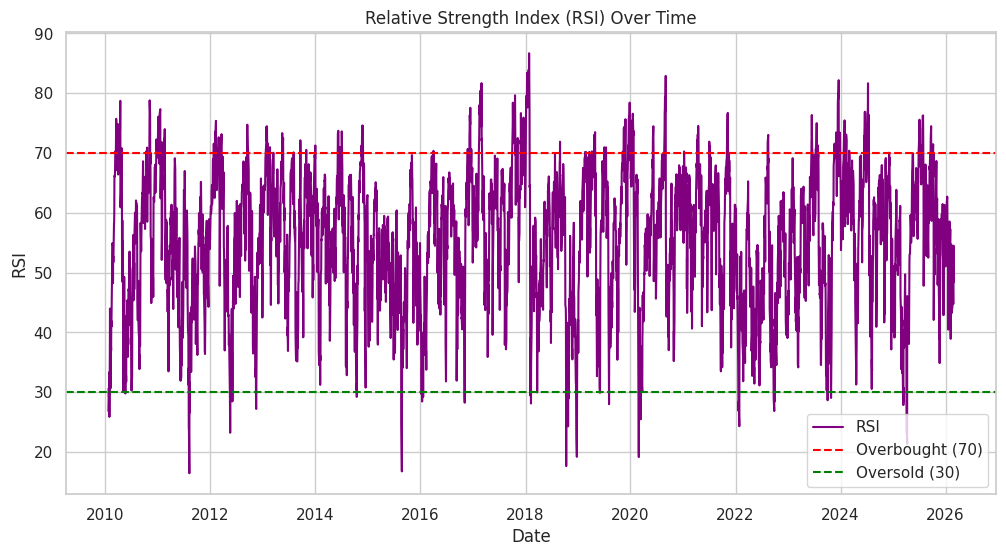

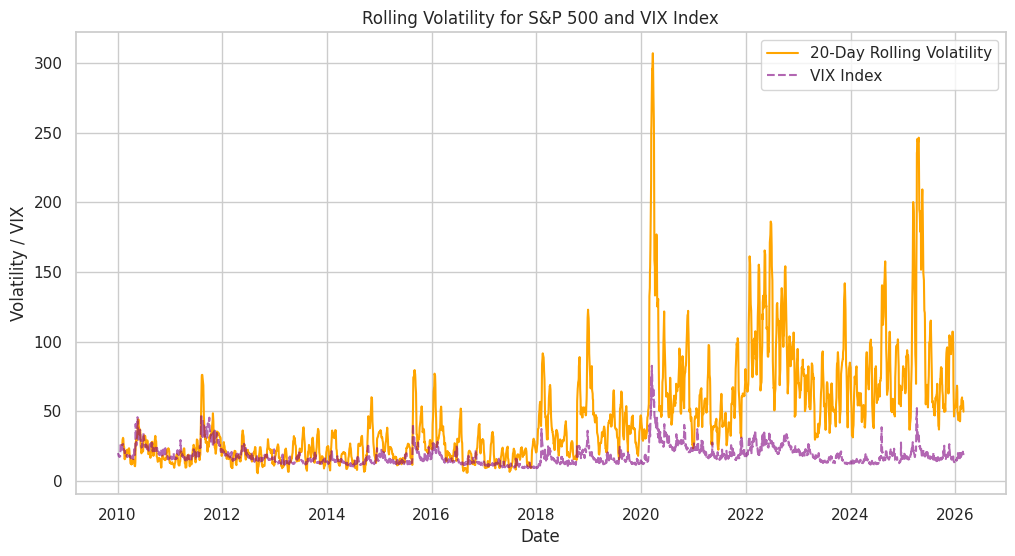

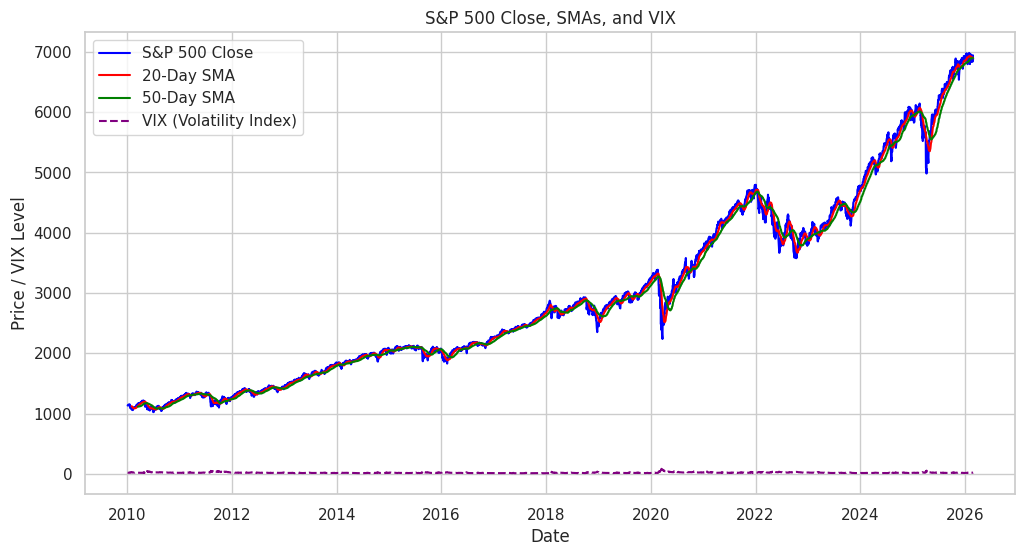

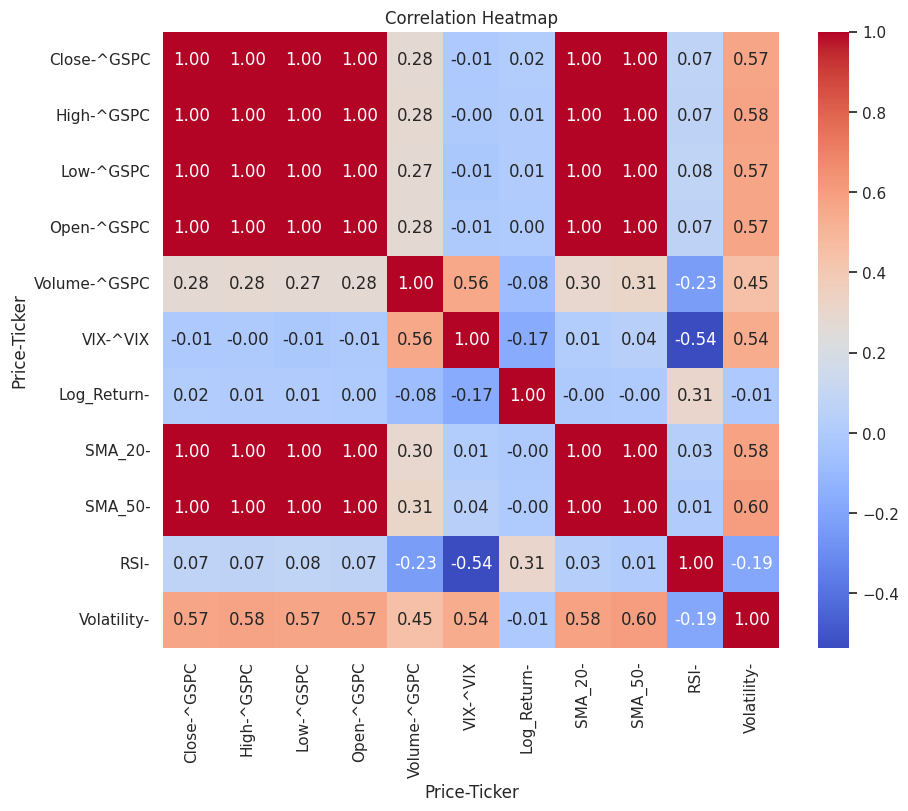

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from datetime import datetime

sns.set(style='whitegrid')

ticker = '^GSPC'
end_date = datetime.today().strftime('%Y-%m-%d')

data = yf.download(ticker, start='2010-01-01', end=end_date, interval='1d')

vix = yf.download('^VIX', start='2010-01-01', end=end_date, interval='1d')
vix = vix[['Close']].rename(columns={'Close': 'VIX'})

data = data.join(vix, how='inner')

print("First few rows of the dataset:")
print(data.head())

print("\nMissing values in the dataset:")
print(data.isnull().sum())

data.dropna(inplace=True)

# log returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# Creating additional features like 20-day simple moving average, 50-day moving average, RSI and Rolling Std
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['RSI'] = ta.momentum.RSIIndicator(data['Close'].squeeze()).rsi()
data['Volatility'] = data['Close'].rolling(window=20).std()

print("\nCleaned data with additional features:")
print(data.head())

# Summary Statistics
print("\nSummary statistics:")
print(data.describe())

# Closing Price Over Time
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Log Returns Distribution
plt.figure(figsize=(12, 6))
sns.histplot(data['Log_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# Time Series of Log Returns
plt.figure(figsize=(12, 6))
plt.plot(data['Log_Return'], label='Log Returns', color='orange')
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', lw=2, linestyle='--')
plt.legend()
plt.show()

# Rolling Mean and Standard Deviation
rolling_mean = data['Close'].rolling(window=20).mean()
rolling_std = data['Close'].rolling(window=20).std()

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(rolling_mean, label='Rolling Mean (20 days)', color='red')
plt.plot(rolling_std, label='Rolling Std Dev (20 days)', color='green')
plt.title('S&P 500 Close Price with Rolling Mean and Std Dev')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['SMA_20'], label='20-Day SMA', color='red')
plt.plot(data['SMA_50'], label='50-Day SMA', color='green')
plt.title('S&P 500 Close Price with 20-Day and 50-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# RSI
plt.figure(figsize=(12, 6))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Relative Strength Index (RSI) Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

# Volatility vs VIX
plt.figure(figsize=(12, 6))
plt.plot(data['Volatility'], label='20-Day Rolling Volatility', color='orange')
plt.plot(data['VIX'], label='VIX Index', color='purple', linestyle='--', alpha=0.6)
plt.title('Rolling Volatility for S&P 500 and VIX Index')
plt.xlabel('Date')
plt.ylabel('Volatility / VIX')
plt.legend()
plt.show()

# VIX
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='S&P 500 Close', color='blue')
plt.plot(data['SMA_20'], label='20-Day SMA', color='red')
plt.plot(data['SMA_50'], label='50-Day SMA', color='green')
plt.plot(data['VIX'], label='VIX (Volatility Index)', color='purple', linestyle='--')
plt.title('S&P 500 Close, SMAs, and VIX')
plt.xlabel('Date')
plt.ylabel('Price / VIX Level')
plt.legend()
plt.show()


# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipython-input-2747/25752723.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start='2010-01-01', end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2747/25752723.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start='2010-01-01', end=end_date)
[*********************100%***********************]  1 of 1 completed


Linear Regression Mean Squared Error: 0.0017413080001510964
Linear Regression R-squared Score: 0.8160346292503302


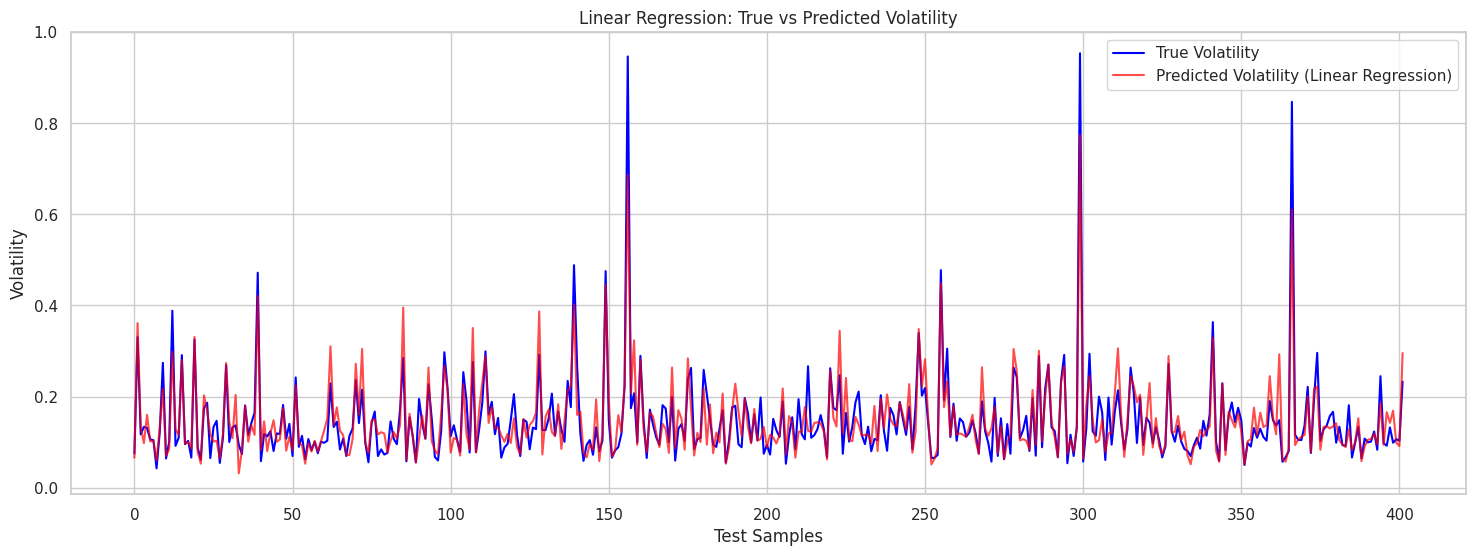

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime

# Set end date to current date
end_date = datetime.today().strftime('%Y-%m-%d')

# Download S&P 500 data
data = yf.download('^GSPC', start='2010-01-01', end=end_date)
data = data[['Close']].copy()

# Feature Engineering
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Volatility'] = data['Log_Return'].rolling(window=21).std() * np.sqrt(252)

# Calculate RSI (Relative Strength Index)
delta = data['Log_Return'].dropna()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# Download VIX data
vix = yf.download('^VIX', start='2010-01-01', end=end_date)
data['VIX'] = vix['Close']

# Drop missing values
data.dropna(inplace=True)

# Features and target variable
X = data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'Log_Return', 'VIX']]  # Features
y = data['Volatility']  # Target: Volatility

# Train-test-validation split: 80% training, 10% validation, 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Linear Regression Model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Predictions
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Evaluation metrics for Linear Regression
lin_reg_mse = mean_squared_error(y_test, y_pred_lin_reg)
lin_reg_r2 = r2_score(y_test, y_pred_lin_reg)

# Print evaluation results
print("Linear Regression Mean Squared Error:", lin_reg_mse)
print("Linear Regression R-squared Score:", lin_reg_r2)

# Plot: True vs Predicted Volatility (Linear Regression)
plt.figure(figsize=(18, 6))
plt.plot(y_test.values, label='True Volatility', color='blue')
plt.plot(y_pred_lin_reg, label='Predicted Volatility (Linear Regression)', color='red', alpha=0.7)
plt.title("Linear Regression: True vs Predicted Volatility")
plt.xlabel("Test Samples")
plt.ylabel("Volatility")
plt.legend()
plt.show()

/tmp/ipython-input-2747/2344783701.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2747/2344783701.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4193.86
Distribution:                  Normal   AIC:                           8395.72
Method:            Maximum Likelihood   BIC:                           8420.06
                                        No. Observations:                 3249
Date:                Sun, Mar 01 2026   Df Residuals:                     3248
Time:                        08:22:20   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0812  1.316e-02      6.171  6.785e-10 [5.543e-0

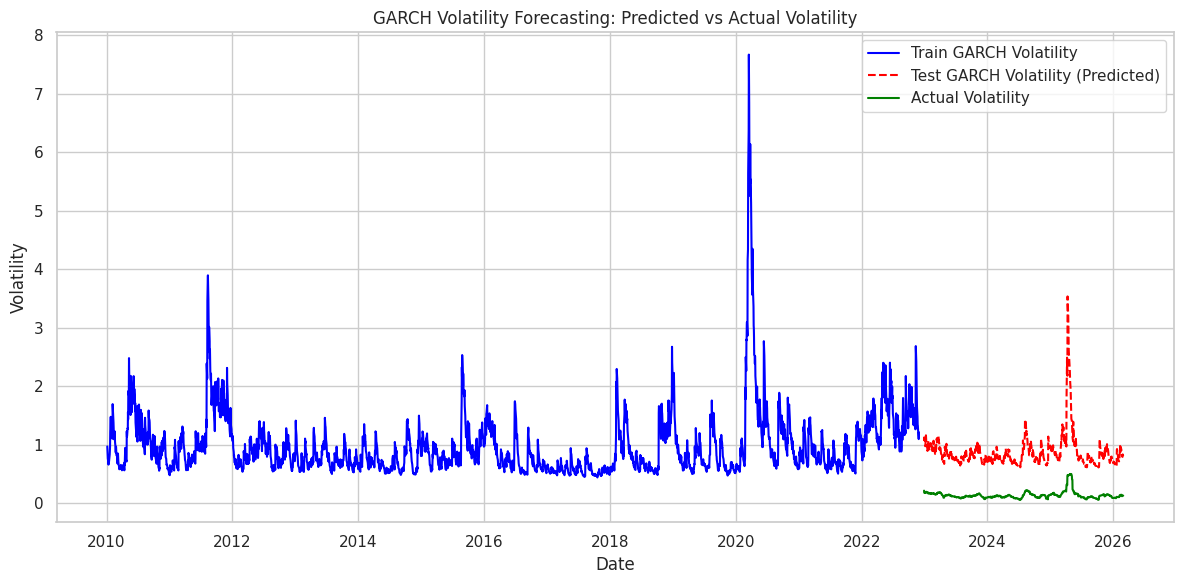

Mean Squared Error (MSE): 0.595638
R-squared (R²): -133.904686


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

# Download the stock data
data = yf.download(ticker, start=start_date, end=end_date)

if data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbol and try again.")

# Flatten MultiIndex columns if present (common with newer yfinance versions)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Calculate daily returns using 'Close'
data['return'] = data['Close'].pct_change()
data = data.dropna()

# Download VIX data
vix = yf.download('^VIX', start=start_date, end=end_date)

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

data['VIX'] = vix['Close']

# Drop NaN values
data = data.dropna()

# Step 2: Split the data into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)
train_data = train_data.copy()
test_data = test_data.copy()

# Step 3: Fit GARCH Model with VIX as an exogenous regressor on training data
model_garch = arch_model(train_data['return'] * 100, vol='Garch', p=1, q=1, x=train_data[['VIX']])
garch_result = model_garch.fit(disp='off')
print(garch_result.summary())

# Step 4: Get the GARCH volatility estimate for training data
train_data = train_data.assign(garch_volatility=garch_result.conditional_volatility)

# Step 5: Generate GARCH Volatility forecasts for the test data
model_garch_test = arch_model(test_data['return'] * 100, vol='Garch', p=1, q=1, x=test_data[['VIX']])
garch_result_test = model_garch_test.fit(disp='off')
test_data = test_data.assign(garch_volatility=garch_result_test.conditional_volatility)

# Step 6: Calculate actual volatility and drop NaNs
actual_vol = test_data['return'].rolling(window=21).std() * np.sqrt(252)
test_data = test_data.assign(actual_volatility=actual_vol).dropna(subset=['actual_volatility'])

# Align garch_volatility index with test_data after dropna
test_data = test_data.dropna(subset=['garch_volatility'])

# Step 7: Visualize the Predicted vs Actual Volatility
plt.figure(figsize=(12, 6))

plt.plot(train_data.index, train_data['garch_volatility'], label='Train GARCH Volatility', color='blue')
plt.plot(test_data.index, test_data['garch_volatility'], label='Test GARCH Volatility (Predicted)', color='red', linestyle='--')
plt.plot(test_data.index, test_data['actual_volatility'], label='Actual Volatility', color='green')

plt.title('GARCH Volatility Forecasting: Predicted vs Actual Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()

# Step 8: Evaluate the GARCH Model Performance (MSE and R²)
mse = mean_squared_error(test_data['actual_volatility'], test_data['garch_volatility'])
print(f"Mean Squared Error (MSE): {mse:.6f}")

r2 = r2_score(test_data['actual_volatility'], test_data['garch_volatility'])
print(f"R-squared (R²): {r2:.6f}")

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0029
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.8433e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.0091e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.7554e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.4879e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.6965e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1192e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.8450e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.9188e-04
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


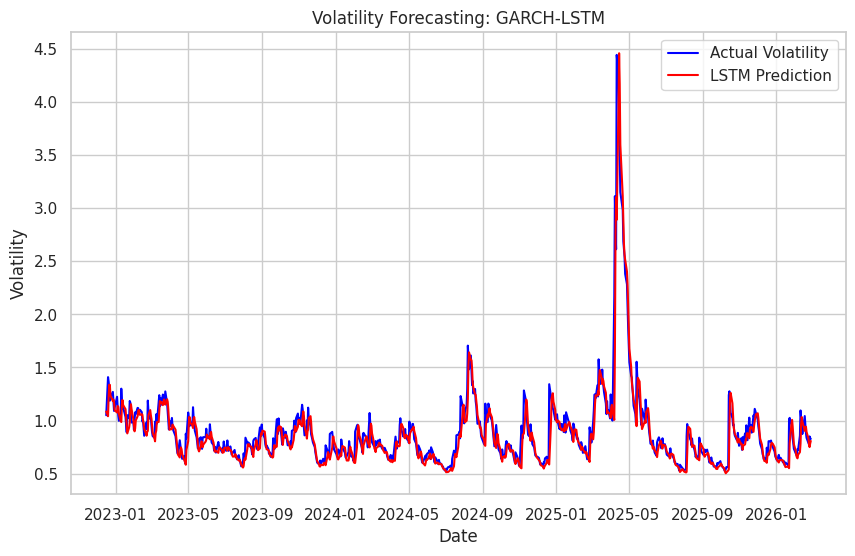

Mean Squared Error (MSE): 0.019369
R-squared (R²): 0.863691


In [ ]:
# GARCH-LSTM

import yfinance as yf
import numpy as np
import tensorflow as tf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime  # ✅ Fix: import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')  # ✅ Now works

# Download the stock data
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)  # ✅ auto_adjust=True handles splits/dividends

# ✅ Fix: Flatten MultiIndex columns (yfinance v0.2+ returns MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

import pandas as pd  # make sure pandas is imported

# Re-flatten after download (safer placement)
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# Check if data was successfully downloaded
if data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbol and try again.")

# ✅ Fix: Use 'Close' instead of 'Adj Close' (auto_adjust=True makes Close = adjusted)
data['return'] = data['Close'].pct_change()

# Drop NaN values
data = data.dropna()

# Step 2: Fit GARCH model to estimate volatility
model_garch = arch_model(data['return'] * 100, vol='Garch', p=1, q=1)
garch_result = model_garch.fit(disp='off')  # ✅ disp='off' silences verbose output

# Get the GARCH volatility estimate
garch_volatility = garch_result.conditional_volatility
data['garch_volatility'] = garch_volatility

# Scale the GARCH volatility for LSTM input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_volatility = scaler.fit_transform(data['garch_volatility'].values.reshape(-1, 1))

# Prepare data for LSTM (past 60 time-steps → predict next)
def create_dataset(volatility, time_step=60):
    X, y = [], []
    for i in range(len(volatility) - time_step - 1):
        X.append(volatility[i:(i + time_step), 0])
        y.append(volatility[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_volatility)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 3: Build the LSTM model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.LSTM(units=50, return_sequences=False),
    tf.keras.layers.Dense(units=1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Step 4: Train the LSTM model
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

# Step 5: Predict and inverse scale
lstm_pred = model_lstm.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 6: Visualize
plt.figure(figsize=(10, 6))
plt.plot(data.index[-len(y_test):], y_test_actual, label='Actual Volatility', color='blue')
plt.plot(data.index[-len(lstm_pred):], lstm_pred, label='LSTM Prediction', color='red')
plt.legend()
plt.title('Volatility Forecasting: GARCH-LSTM')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# Step 7: Evaluation Metrics
mse = mean_squared_error(y_test_actual, lstm_pred)
r2 = r2_score(y_test_actual, lstm_pred)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R²): {r2:.6f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0157e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.3715e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6100e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4814e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.5344e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.2305e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3095e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3808e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7912e-04
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Mean Squared Error (MSE): 0.016469
R-squared (R²): 0.884101


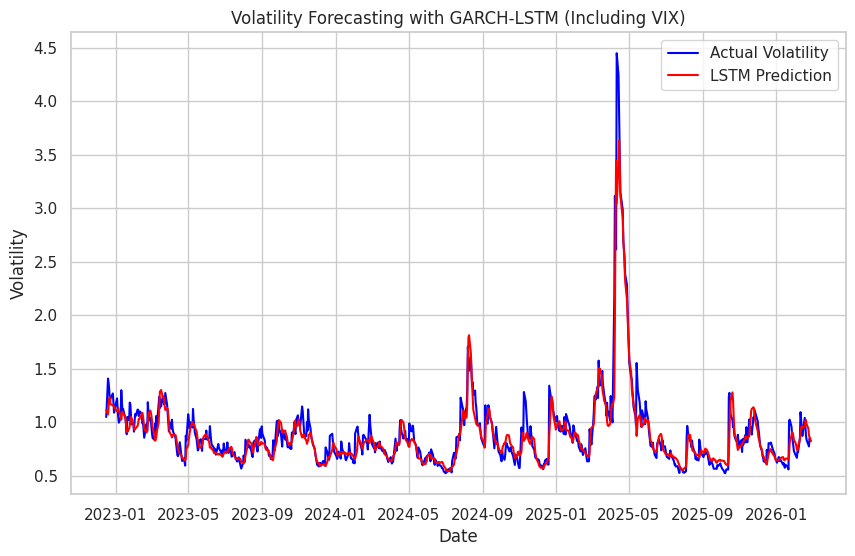

In [ ]:
# GARCH-LSTM (with VIX)

import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime  # ✅ Fix: import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
vix_ticker = '^VIX'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')  # ✅ Always uses today's date

# Download the S&P 500 data
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)  # ✅ auto_adjust replaces Adj Close

# Download the VIX data
vix_data = yf.download(vix_ticker, start=start_date, end=end_date, auto_adjust=True)

# ✅ Fix: Flatten MultiIndex columns (yfinance v0.2+ returns MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if isinstance(vix_data.columns, pd.MultiIndex):
    vix_data.columns = vix_data.columns.get_level_values(0)

# Check if data was successfully downloaded
if data.empty or vix_data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbols and try again.")

# ✅ Fix: Use 'Close' instead of 'Adj Close' (auto_adjust=True makes Close = adjusted)
data['return'] = data['Close'].pct_change()

# Drop NaN values
data = data.dropna()

# Align the VIX data with the S&P 500 data
data['vix'] = vix_data['Close'].reindex(data.index, method='ffill')  # ✅ Fix: 'Close' instead of 'Adj Close'

# Drop any remaining NaN values after VIX alignment
data = data.dropna()

# Step 2: Fit GARCH model to estimate volatility
model_garch = arch_model(data['return'] * 100, vol='Garch', p=1, q=1)
garch_result = model_garch.fit(disp='off')  # ✅ disp='off' silences verbose output

# Get the GARCH volatility estimate
garch_volatility = garch_result.conditional_volatility
data['garch_volatility'] = garch_volatility

# Scale the GARCH volatility and VIX for LSTM input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['garch_volatility', 'vix']].values)

# Step 3: Prepare the data for LSTM (past 60 time-steps → predict next)
def create_dataset(volatility, time_step=60):
    X, y = [], []
    for i in range(len(volatility) - time_step - 1):
        X.append(volatility[i:(i + time_step), :])  # Input: past volatility + VIX
        y.append(volatility[i + time_step, 0])       # Output: future volatility
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])  # (samples, time steps, features)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 4: Build the LSTM model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(units=50, return_sequences=False),
    tf.keras.layers.Dense(units=1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Step 5: Train the LSTM model
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

# Step 6: Predict and inverse scale
lstm_pred = model_lstm.predict(X_test)
lstm_pred_inv = scaler.inverse_transform(
    np.concatenate([lstm_pred, np.zeros((lstm_pred.shape[0], 1))], axis=1)
)[:, 0]

# Inverse scale actual values
y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 1))], axis=1)
)[:, 0]

# Step 7: Evaluation Metrics
mse = mean_squared_error(y_test_inv, lstm_pred_inv)
r2 = r2_score(y_test_inv, lstm_pred_inv)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R²): {r2:.6f}")

# Step 8: Visualize Predictions
plt.figure(figsize=(10, 6))
plt.plot(data.index[-len(y_test):], y_test_inv, label='Actual Volatility', color='blue')
plt.plot(data.index[-len(lstm_pred_inv):], lstm_pred_inv, label='LSTM Prediction', color='red')
plt.legend()
plt.title('Volatility Forecasting with GARCH-LSTM (Including VIX)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0024
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.0554e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.9977e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.9317e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.6225e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0766e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4893e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7536e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.9642e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4200e-04
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


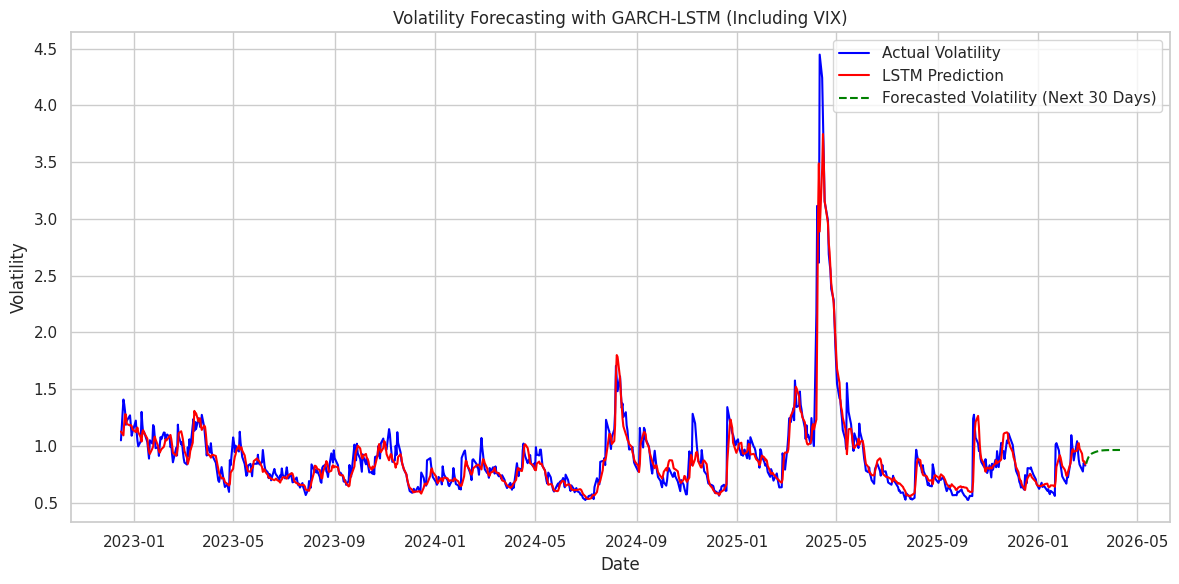


📅 Forecasting from 2026-02-27 → 2026-04-10

Forecasted Volatility for 2026-02-28: 0.8440
Forecasted Volatility for 2026-03-01: 0.8673
Forecasted Volatility for 2026-03-02: 0.8879
Forecasted Volatility for 2026-03-03: 0.9037
Forecasted Volatility for 2026-03-04: 0.9152
Forecasted Volatility for 2026-03-05: 0.9234
Forecasted Volatility for 2026-03-06: 0.9293
Forecasted Volatility for 2026-03-07: 0.9338
Forecasted Volatility for 2026-03-08: 0.9375
Forecasted Volatility for 2026-03-09: 0.9408
Forecasted Volatility for 2026-03-10: 0.9437
Forecasted Volatility for 2026-03-11: 0.9465
Forecasted Volatility for 2026-03-12: 0.9491
Forecasted Volatility for 2026-03-13: 0.9515
Forecasted Volatility for 2026-03-14: 0.9536
Forecasted Volatility for 2026-03-15: 0.9555
Forecasted Volatility for 2026-03-16: 0.9571
Forecasted Volatility for 2026-03-17: 0.9585
Forecasted Volatility for 2026-03-18: 0.9597
Forecasted Volatility for 2026-03-19: 0.9606
Forecasted Volatility for 2026-03-20: 0.9614
Forecasted

In [ ]:
# Prediction

import yfinance as yf
import numpy as np
import tensorflow as tf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime  # ✅ Fix: import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
vix_ticker = '^VIX'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')  # ✅ Always uses today's date

# Download the S&P 500 and VIX data
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)      # ✅ auto_adjust=True
vix_data = yf.download(vix_ticker, start=start_date, end=end_date, auto_adjust=True)

# ✅ Fix: Flatten MultiIndex columns (yfinance v0.2+ returns MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if isinstance(vix_data.columns, pd.MultiIndex):
    vix_data.columns = vix_data.columns.get_level_values(0)

# Check if data was successfully downloaded
if data.empty or vix_data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbols and try again.")

# ✅ Fix: Use 'Close' instead of 'Adj Close'
data['return'] = data['Close'].pct_change()
data = data.dropna()

# Align the VIX data with the S&P 500 data
data['vix'] = vix_data['Close'].reindex(data.index, method='ffill')  # ✅ Fix: 'Close'
data = data.dropna()  # Drop any NaN after VIX alignment

# Step 2: Fit GARCH model to estimate volatility
model_garch = arch_model(data['return'] * 100, vol='Garch', p=1, q=1)
garch_result = model_garch.fit(disp='off')  # ✅ disp='off' silences verbose output

# Get the GARCH volatility estimate
garch_volatility = garch_result.conditional_volatility
data['garch_volatility'] = garch_volatility

# Step 3: Scale the GARCH volatility and VIX for LSTM input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['garch_volatility', 'vix']].values)

# Step 4: Prepare the data for LSTM (past 60 time-steps → predict next)
def create_dataset(volatility, time_step=60):
    X, y = [], []
    for i in range(len(volatility) - time_step - 1):
        X.append(volatility[i:(i + time_step), :])
        y.append(volatility[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])  # (samples, time steps, features)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 5: Build the LSTM model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(units=50, return_sequences=False),
    tf.keras.layers.Dense(units=1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Step 6: Train the LSTM model
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

# Step 7: Predict volatility using the LSTM model
lstm_pred = model_lstm.predict(X_test)
lstm_pred_inv = scaler.inverse_transform(
    np.concatenate([lstm_pred, np.zeros((lstm_pred.shape[0], 1))], axis=1)
)[:, 0]

# Inverse scale actual test values
y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 1))], axis=1)
)[:, 0]

# Step 8: Forecasting 30 days into the future from today
last_time_steps = scaled_data[-60:].copy()  # Last 60 time steps (scaled)

# ✅ Updated: forecast 30 business days ahead from the last data point
forecast_target = datetime.today() + pd.offsets.BDay(30)
forecast_days = max(1, (forecast_target - data.index[-1]).days)

predictions = []
dates = []

for i in range(forecast_days):
    input_seq = last_time_steps.reshape((1, 60, 2))

    # Predict the next volatility (scaled)
    predicted_scaled = model_lstm.predict(input_seq, verbose=0)

    # Inverse scale to get real volatility value
    predicted_volatility = scaler.inverse_transform(
        np.concatenate([predicted_scaled, np.zeros((1, 1))], axis=1)
    )[:, 0][0]

    # Get the most recent available VIX value for the forecasted date
    predicted_date = data.index[-1] + pd.Timedelta(days=i + 1)
    latest_vix_scaled = last_time_steps[-1, 1]  # ✅ Use last known scaled VIX value

    # Build new scaled row: [scaled predicted vol, last known scaled VIX]
    new_row_scaled = np.array([[predicted_scaled[0, 0], latest_vix_scaled]])

    # Shift the window: drop oldest, append new prediction
    last_time_steps = np.vstack([last_time_steps[1:], new_row_scaled])

    predictions.append(predicted_volatility)
    dates.append(predicted_date)

# Step 9: Plot actual, predicted, and forecasted volatility
plt.figure(figsize=(12, 6))
plt.plot(data.index[-len(y_test):], y_test_inv, label='Actual Volatility', color='blue')
plt.plot(data.index[-len(lstm_pred_inv):], lstm_pred_inv, label='LSTM Prediction', color='red')
plt.plot(dates, predictions, label='Forecasted Volatility (Next 30 Days)', color='green', linestyle='dashed')
plt.legend()
plt.title('Volatility Forecasting with GARCH-LSTM (Including VIX)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.tight_layout()
plt.show()

# Print forecasted values
print(f"\n📅 Forecasting from {data.index[-1].date()} → {forecast_target.date()}\n")
for forecast_date, forecast_value in zip(dates, predictions):
    print(f"Forecasted Volatility for {forecast_date.date()}: {forecast_value:.4f}")

[*********************100%***********************]  1 of 1 completed


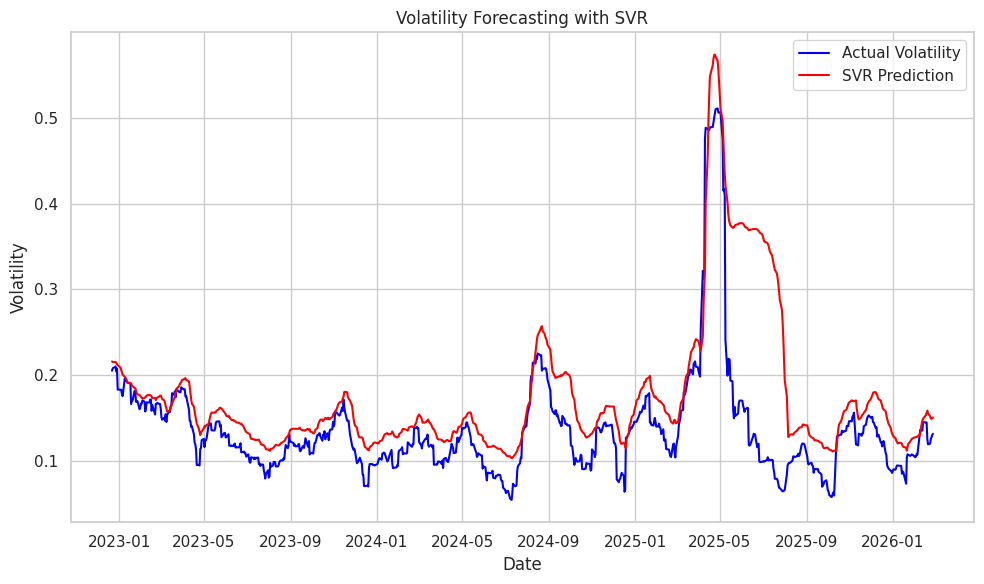

Mean Squared Error (MSE): 0.004552
R-squared (R²): -0.014591


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime  # ✅ Fix: import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')  # ✅ Always uses today's date

# Download the stock data
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)  # ✅ auto_adjust=True

# ✅ Fix: Flatten MultiIndex columns (yfinance v0.2+ returns MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Check if data was successfully downloaded
if data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbol and try again.")

# ✅ Fix: Use 'Close' instead of 'Adj Close'
data['return'] = data['Close'].pct_change()
data = data.dropna()

# Step 2: Preprocess the data for SVR model

# 2.1: Rolling window to calculate historical volatility (annualized)
window_size = 20
data['volatility'] = data['return'].rolling(window=window_size).std() * np.sqrt(252)
data = data.dropna()

# 2.2: Scale the volatility for SVR input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_volatility = scaler.fit_transform(data['volatility'].values.reshape(-1, 1))

# 2.3: Prepare the data for SVR (past 60 time-steps → predict next)
def create_dataset(volatility, time_step=60):
    X, y = [], []
    for i in range(len(volatility) - time_step - 1):
        X.append(volatility[i:(i + time_step), 0])
        y.append(volatility[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_volatility)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 3: Build and train the SVR model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)

# Step 4: Predict and inverse scale
svr_pred = svr_model.predict(X_test)
svr_pred_inv = scaler.inverse_transform(svr_pred.reshape(-1, 1))

# Inverse scale actual test values
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 5: Visualize Predictions
plt.figure(figsize=(10, 6))
plt.plot(data.index[-len(y_test):], y_test_inv, label='Actual Volatility', color='blue')
plt.plot(data.index[-len(svr_pred_inv):], svr_pred_inv, label='SVR Prediction', color='red')
plt.legend()
plt.title('Volatility Forecasting with SVR')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.tight_layout()
plt.show()

# Step 6: Evaluation Metrics
mse = mean_squared_error(y_test_inv, svr_pred_inv)
r2 = r2_score(y_test_inv, svr_pred_inv)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R²): {r2:.6f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


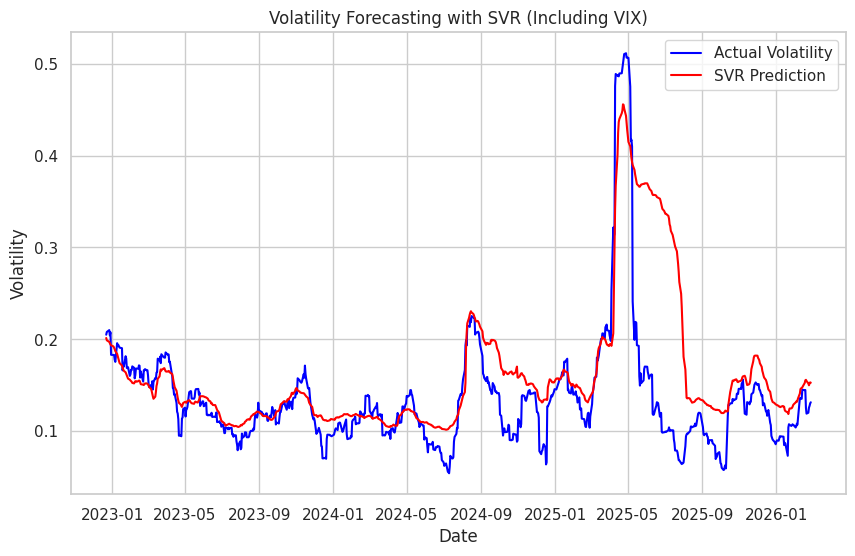

Mean Squared Error (MSE): 0.003891
R-squared (R²): 0.132669


In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime

# Step 1: Download the data from Yahoo Finance
ticker = '^GSPC'
vix_ticker = '^VIX'
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

# Download the stock data
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)  # ✅ auto_adjust=True
vix_data = yf.download(vix_ticker, start=start_date, end=end_date, auto_adjust=True)  # ✅ auto_adjust=True

# Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):  # ✅ Handle MultiIndex
    data.columns = data.columns.get_level_values(0)
if isinstance(vix_data.columns, pd.MultiIndex):
    vix_data.columns = vix_data.columns.get_level_values(0)

# Check if data was successfully downloaded
if data.empty or vix_data.empty:
    raise ValueError("No data downloaded. Please check the ticker symbols and try again.")

# Calculate daily returns using 'Close' instead of 'Adj Close'
data['return'] = data['Close'].pct_change()  # ✅ 'Close' replaces 'Adj Close'

# Drop NaN values created by pct_change
data = data.dropna()

# Step 2: Preprocess the data for SVR model

# 2.1: Rolling window to calculate historical volatility
window_size = 20
data['volatility'] = data['return'].rolling(window=window_size).std() * np.sqrt(252)

# Drop NaN values caused by rolling window
data = data.dropna()

# 2.2: Add VIX data to the dataset
data['vix'] = vix_data['Close'].reindex(data.index, method='ffill')  # ✅ 'Close' replaces 'Adj Close'

# 2.3: Scale the volatility and VIX for SVR input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['volatility', 'vix']].values)

# Step 3: Prepare the data for SVR (using past 60 time-steps to predict next)
def create_dataset(features, time_step=60):
    X, y = [], []
    for i in range(len(features) - time_step - 1):
        X.append(features[i:(i + time_step), :])
        y.append(features[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 4: Build and train the SVR model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

# Step 5: Predict volatility using the SVR model
svr_pred = svr_model.predict(X_test.reshape(X_test.shape[0], -1))

# Inverse scaling to get original volatility values
svr_pred = scaler.inverse_transform(np.concatenate([svr_pred.reshape(-1, 1), np.zeros((svr_pred.shape[0], 1))], axis=1))[:, 0]

# Step 6: Visualize Predictions
plt.figure(figsize=(10, 6))
actual = scaler.inverse_transform(np.concatenate([y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 1))], axis=1))[:, 0]

plt.plot(data.index[-len(y_test):], actual, label='Actual Volatility', color='blue')
plt.plot(data.index[-len(svr_pred):], svr_pred, label='SVR Prediction', color='red')
plt.legend()
plt.title('Volatility Forecasting with SVR (Including VIX)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# Step 7: Evaluation Metrics
mse = mean_squared_error(actual, svr_pred)
r2 = r2_score(actual, svr_pred)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R²): {r2:.6f}")